# Will the Fed raise or cut rates?
#### Fine-tune a model on what they say. Mortgage and car-loan rates can move with it.


The Federal Open Market Committee (FOMC) is the Fed group that sets the federal funds rate, the overnight rate banks charge each other. That is not your mortgage or car-loan APR. Markets still read the minutes, press conferences, and speeches for whether the Fed is leaning **raise / cut / hold**. That lean can move longer-term rates, which is often how mortgages, car loans, and credit cards reprice, but not one-for-one. When the committee sounds **hawkish**, they are leaning toward tighter policy (higher rates to cool inflation). When they sound **dovish**, they are leaning toward easier policy (lower rates to support growth).

[Shah et al. (2023)](https://aclanthology.org/2023.acl-long.368/) turn that reading into a three-way label on FOMC sentences (hawkish / dovish / neutral). We follow their Combined-S recipe. LoRA and QLoRA are the only change to the trainer. **Flyte 2 is one `workflow.py`:** this MacBook Pro (`flyte run --local`, MPS), then the same tasks on a remote NVIDIA GPU (RTX PRO 6000 Blackwell or H200). Adding [`nvidia/NVIDIA-Nemotron-3-Nano-4B-BF16`](https://huggingface.co/nvidia/NVIDIA-Nemotron-3-Nano-4B-BF16) is another `--model_key` on that DAG, same data, same table, not a second repo.

- Why Fed language can show up in mortgage and car-loan rates
- One pipeline: laptop → remote GPU (change the command, not the graph)
- RoBERTa-base / large, then Nemotron-3-Nano-4B on the same Combined-S labels
- Full vs LoRA vs QLoRA, 3-seed F1 vs their Table 5


## One pipeline

![](images/flyte_pipeline.png)

*Image Credit: original diagram for this tutorial.*

A training script is enough to fine-tune RoBERTa **once, on one box**. It is the wrong shape the moment you have **two machines**, **CPU work mixed with GPU work**, and a **grid** (two encoder sizes × three methods × three seeds, then a 4B causal LM on the same labels). **Flyte 2 is one `workflow.py`.** Change the command, not the pipeline.

- **Laptop**: `flyte run --local` on this MacBook Pro (MPS). RoBERTa full + LoRA. No Docker.
- **1 GPU**: `FLYTE_GPUS=1`. Serial 2×3 + QLoRA on one Blackwell card. Same F1 as 1 GPU/job.
- **1 GPU/job**: `--parallel jobs` on a 4-GPU node. Four cells at once, one card each, not one RoBERTa run split across four GPUs.
- **One DAG**: CPU `prepare_data`, GPU `train_one` / `grid`. Add `nemotron-nano-4b` the way you add `roberta-large`.
- **Skip / retry**: a finished `metrics.json` is skipped; one failed cell retries, not the whole grid.
- **Same UI**: Sub actions, Input, Output, Reports on the laptop and on the GPU node.

`--local` means *this process on this machine* (Mac or the GPU node). The Flyte GPU **devbox** is the later laptop path for watching a remote run in the browser when Docker is available. Commands are in **CLI**.


## Task
![](images/hawkish_dovish_task.png)

*Image Credit: original diagram for this tutorial.*

*Idea Credit: [Shah et al. (2023)](https://aclanthology.org/2023.acl-long.368/). Example sentences are illustrative, not quoted from the paper.*


[Shah et al. (2023)](https://aclanthology.org/2023.acl-long.368/) label FOMC minutes, pressers, and speeches as dovish / hawkish / neutral. Combined-S is ~2,480 sentences (1996–2022), seeds `5768`, `78516`, `944601`, random 80/20, not a year cutoff. Table 5 weighted F1: RoBERTa-base **0.698 ± 0.010**, RoBERTa-large **0.711 ± 0.011**. Data: [gtfintechlab/fomc-hawkish-dovish](https://github.com/gtfintechlab/fomc-hawkish-dovish) (CC BY-NC 4.0). Released model: [`gtfintechlab/FOMC-RoBERTa`](https://huggingface.co/gtfintechlab/FOMC-RoBERTa).

Their loop: AdamW, max length 256, 20% val, patience 7, last checkpoint. Combined-S winners: base batch 8 / 1e-5, large batch 16 / 1e-5. We keep that loop; LoRA / QLoRA only change adapters.


## Full fine-tuning vs LoRA vs QLoRA
![](images/full_lora_qlora.png)

*Image Credit: original diagram for this tutorial.*

*Idea Credit: LoRA, [Hu et al., 2021](https://arxiv.org/abs/2106.09685); QLoRA, [Dettmers et al., 2023](https://arxiv.org/abs/2305.14314).*


**Full fine-tuning** updates every weight, the setup in Shah et al. (2023), and our quality target.

**LoRA** ([Hu et al., 2021](https://arxiv.org/abs/2106.09685)) freezes \(W\) and trains \(A \times B\), scaled by \(\alpha / r\). On RoBERTa we target `query`, `key`, `value`, `dense` and fully train the head (`modules_to_save=["classifier"]`).

**QLoRA** ([Dettmers et al., 2023](https://arxiv.org/abs/2305.14314)) keeps those adapters and stores the frozen base in 4-bit (NF4) via [bitsandbytes](https://github.com/bitsandbytes-foundation/bitsandbytes). That path needs **NVIDIA CUDA**, not MPS. This Mac runs RoBERTa-base + large, full and LoRA. A remote Blackwell or H200 runs that 2×3 including QLoRA, then **Nemotron-3-Nano-4B** as three more rows on the same table.

Peak GPU memory is the sum of four buckets. **Trainable % only shrinks grads and AdamW.** The forward still runs the full model, so activations stay.

![](images/ft_memory_budget.png)

*Image Credit: original diagram for this tutorial.*

*Idea Credit: unit-square GPU memory budget used in LoRA / QLoRA talks (parameters, gradients, optimizer, activations).*

| Bucket | What lives there | Full FT | LoRA | QLoRA |
|---|---|---|---|---|
| **Weights** | stored parameters | every layer, fp32 / bf16 | same (base frozen, still resident) | base in **NF4**; adapters in fp32 / bf16 |
| **Gradients** | \(dL/dW\) for the update | one tensor per weight | adapters + classifier only | same as LoRA |
| **AdamW** | two running stats (\(m\), \(v\)) per trainable param | **all** weights, often the largest static cost on a 4B model | adapters + classifier only | same as LoRA |
| **Activations** | tensors kept for backward (batch × seq × hidden × layers) | full graph | **same graph** | same graph, plus short-lived dequant workspace |

A step still does a full forward and a backward through that graph. LoRA does not skip layers; it skips **optimizer state on the frozen weights**. That is why LoRA/QLoRA can look *slower* in the Results table (more epochs to early-stop) while using **less memory**.

On RoBERTa the activation bucket dominates (batch 8 / 16, length 256), so the measured CUDA drop is modest: base **3.1 → 2.2 → 1.9 GB**, large **10.5 → 9.9 → 8.9 GB** (full / LoRA / QLoRA). On Nemotron-4B the static gap is large (AdamW on ~4B vs ~68M). Without `causal-conv1d` the activations also include the naive Mamba \(L^2\) workspace, the card-filling term, not the adapter count (first-grid LoRA / QLoRA peaks: **13.9 GB** / **9.6 GB** on the RTX PRO 6000). With the fused Mamba kernels, `labeltok` QLoRA peaks at **~5.4 GB** on the 24 GB laptop.

Checkpoints: `checkpoints/`. Resume is the default; `FORCE = True` starts over.


## Training and evaluating on Combined-S

Run from `02_fomc_roberta`. Same `workflow.py` as the CLI. The grid resumes from `metrics.json`; `FORCE = True` starts over.

In [1]:
from pathlib import Path
import os

os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

import flyte
import flyte.report  # required, import flyte does not load this submodule

import config as cfg
from device_utils import describe, detect_device, has_nvidia
from flyte_env import cpu_env, gpu_env, ui_env
from load_data import train_val_test
from paper_baselines import paper_table
from run_grid import (
    collect_completed,
    format_per_seed,
    format_results,
    load_runs,
    machine_label,
    merge_report_runs,
    style_results_by_machine,
    summarize_runs,
)
from train_run import load_trained, predict_texts
from workflow import grid, main, pipeline, prepare_data, train_one

ROOT = Path.cwd()
assert (ROOT / "workflow.py").exists(), f"Run this notebook from 02_fomc_roberta (cwd={ROOT})"
print("Working directory:", ROOT)
print("Device:", describe())
print("NVIDIA / QLoRA:", has_nvidia())
print("TaskEnvironments:", cpu_env.name, gpu_env.name, ui_env.name)
print("Nemotron uses the same gpu_env, --model_key nemotron-nano-4b")

# Same objects as workflow.py / flyte_env.py
print("\n--- flyte_env.py (TaskEnvironment) ---\n")
print((ROOT / "flyte_env.py").read_text())
_src = (ROOT / "workflow.py").read_text()
_i = _src.index("@gpu_env.task")
print("--- workflow.py @gpu_env.task train_one ---\n")
print(_src[_i : _i + 700])

# No Docker on this GPU host, so no GPU devbox. False = in-process on this machine.
USE_DEVBOX = False
FORCE = False
SMOKE = False
MAX_EPOCHS = 2 if SMOKE else None

if USE_DEVBOX:
    flyte.init_from_config(ROOT / ".flyte/devbox.yaml")
    print("flyte.init_from_config(.flyte/devbox.yaml), browser at http://localhost:30080/v2")
else:
    flyte.init()
    print("flyte.init(), in-process on this machine (CUDA if this is the GPU job).")


/home/mgalarnyk/projects/Python_Tutorials/NLP/Fine_Tuning/02_fomc_roberta/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Working directory: /home/mgalarnyk/projects/Python_Tutorials/NLP/Fine_Tuning/02_fomc_roberta
Device: cuda (NVIDIA RTX PRO 5000 Blackwell Generation Laptop GPU)
NVIDIA / QLoRA: True
TaskEnvironments: fomc-roberta-cpu fomc-roberta-gpu fomc-roberta-ui
Nemotron uses the same gpu_env, --model_key nemotron-nano-4b

--- flyte_env.py (TaskEnvironment) ---

"""Flyte 2 task environments: CPU for data, GPU for the paper-loop train."""

from __future__ import annotations

import os
import shutil

import flyte
import flyte.app
from flyteplugins.vllm import VLLMAppEnvironment

# Flyte resource GPU count is NVIDIA. On this MacBook Pro, request 0 so
# --local still runs; PyTorch uses MPS inside the task. Devbox: `flyte start
# devbox` here (no --gpu; Apple Silicon unsupported). On a remote NVIDIA
# RTX PRO 6000 Blackwell (96 GB): `flyte start devbox --gpu`, default 1 GPU.
# Set FLYTE_GPUS=4 only when a task should own four cards (DDP). For
# 1 GPU/job on a 4-GPU node keep FLYTE_GPUS=1 and pass --paral

### Step 1: Load the paper's splits

Files come from [gtfintechlab/fomc-hawkish-dovish](https://github.com/gtfintechlab/fomc-hawkish-dovish) (CC BY-NC 4.0). They are **not** stored in git. Default split is Combined-S: `lab-manual-split-combine`.

In [2]:
# Each paper seed has its own train/test xlsx. Peek at seed 5768; the grid trains all three.
train, val, test = train_val_test(seed=cfg.PAPER_SEEDS[0], split=cfg.DEFAULT_SPLIT)
print(f"seed={cfg.PAPER_SEEDS[0]}  train={len(train):,}  val={len(val):,}  test={len(test):,}")
print("\nTrain label counts:")
print(train["label_name"].value_counts())
train.head(3)

seed=5768  train=1,588  val=396  test=496

Train label counts:
label_name
neutral    784
dovish     416
hawkish    388
Name: count, dtype: int64


,text,label,label_name
0,"However, economic activity continued to be dep...",2,neutral
1,To abstract from the potential effects of cycl...,2,neutral
2,"Thus, avoiding a further substantial fall in i...",0,dovish


### Step 2: Confirm labels and the published Table 5 numbers

| Id | Name | Policy stance |
|----|------|----------------|
| 0 | dovish | Easing / more accommodative |
| 1 | hawkish | Tightening / less accommodative |
| 2 | neutral | No clear stance |

Paper metric is **weighted F1**. Combined-S: RoBERTa-base **0.698**, RoBERTa-large **0.711**. Combined (no sentence split): large **0.717**: that is their headline number.

In [3]:
paper_table(cfg.DEFAULT_SPLIT)

,who,model,method,split,weighted_f1,weighted_f1_std
0,"Shah et al. (full FT, 3-seed mean)",roberta-base,full,lab-manual-split-combine,0.6981,0.0097
1,"Shah et al. (full FT, 3-seed mean)",roberta-large,full,lab-manual-split-combine,0.7113,0.0106


### Four GPUs: 1 GPU per job

The CUDA RoBERTa grid is six cells: base and large, each with full, LoRA, and QLoRA (three seeds, 18 runs). Nemotron-3-Nano-4B is three more method cells on that same yellow CUDA block. On **one** card those jobs run one after another.

On **four** cards, `bash run_fomc.sh jobs` is still **1 GPU per job**: four unfinished cells at once, each single-device. F1 is the yellow 1-GPU row, we do not add a second table block. The number that drops is **grid wall-clock**. Do not split one RoBERTa run across four cards: the paper loop is single-device, the model already fits in ~10 GB, and DDP would change the effective batch vs Table 5.

QLoRA stays CUDA-only. This Mac still runs the four MPS cells (base/large × full/LoRA).


### Step 3: Train the comparison grid

| Method | What trains | Typical machine |
|--------|-------------|-----------------|
| Full | All encoder + classifier weights | MacBook Pro (M4 Max, 128 GB, MPS) |
| LoRA | Adapters on `query`, `key`, `value`, `dense` + classifier | MacBook Pro (M4 Max, 128 GB, MPS) |
| QLoRA | LoRA + 4-bit frozen base | RTX PRO 6000 Blackwell, 96 GB, or RTX PRO 5000 laptop, 24 GB (CUDA) |
| Nemotron-3-Nano-4B | Same Combined-S labels. `labeltok` recipe: Shah tightening/easing definitions, LM-head label tokens, LoRA r=64, lr 1e-4, accum 16, cosine, best val-F1 ckpt | RTX PRO 5000 laptop, 24 GB (QLoRA, ~5.4 GB peak) |

Laptop: `flyte run --local` (this Mac, MPS). Remote GPU: `bash run_fomc.sh` (in-process CUDA). Same `workflow.py`. Finished `metrics.json` is skipped unless `FORCE = True`.


In [4]:
# Same functions as `flyte run workflow.py pipeline` / `grid`.
# USE_DEVBOX from the import cell: True = remote GPU devbox; False = in-process / --local
r = flyte.run(
    pipeline,
    model_key="roberta-base",
    method="lora",
    seed=cfg.DEFAULT_SEED,
    max_epochs=MAX_EPOCHS,
    force=FORCE,
)
print(r.name)
print(getattr(r, "url", ""))
r.wait()
print(r.outputs)


[b6bc45db-0257-482c-bc52-7871cfdc1230][dgas0ap7uowq7pqrlj8qxhjwa] FOMC pipeline: roberta-base lora seed=5768  (local MPS or remote RTX PRO 6000 Blackwell)


[fomc] DONE (cached) roberta-base lora seed=5768  F1=0.6679411784013302  /home/mgalarnyk/projects/Python_Tutorials/NLP/Fine_Tuning/02_fomc_roberta/checkpoints/roberta-base__lora__lab-manual-split-combine__seed5768__paper/metrics.json


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 4337.78it/s]

dry-run
/tmp/flyte/metadata/b6bc45db-0257-482c-bc52-7871cfdc1230


## Results

Weighted F1, mean ± std over seeds `5768`, `78516`, `944601` on Combined-S, as in Table 5 of [Shah et al. (2023)](https://aclanthology.org/2023.acl-long.368/). Mac times are typical lid-open runs.

**Time** is wall-clock for the **whole cell** (early-stop included). **Time/epoch** is Time / Epochs. vs paper uses their full-FT Table 5 number; Nemotron rows use the RoBERTa-large Table 5 mean as the quality bar. **Nemotron-3-Nano-4B QLoRA** (`labeltok` recipe, fused Mamba kernels) finished all three seeds on the **RTX PRO 5000 Blackwell laptop (24 GB)**: test weighted F1 **0.716 ± 0.015**, level with Shah et al.'s fully fine-tuned RoBERTa-large (0.711 ± 0.011), at ~5.4 GB peak and ~1 h per seed. The first Nemotron grid (linear head, naive Mamba `torch_forward`, RTX PRO 6000) scored **0.489 ± 0.011** / **0.510 ± 0.050** (LoRA / QLoRA), about 0.20 below RoBERTa-large; those rows are kept below, labeled *first grid*. Full FT hit early-stop (19 / 19 / 13 epochs) then died on `save_pretrained` (Nemotron ships `top_p=0.95` with `do_sample` unset), so that F1 is still `-`. RoBERTa-large full on CUDA is pulled down by seed `944601` (test F1 0.331, only predicted neutral). `bash run_fomc.sh jobs` is the same single-device recipe on four cards at once, same F1, so it is not a second block in this table.

Rows are colored by machine.

<span style="display:inline-block;margin:0 10px 6px 0;padding:2px 8px;border-radius:999px;background:#eef0f3;font-size:0.82em">Shah et al. · RTX A6000</span>
<span style="display:inline-block;margin:0 10px 6px 0;padding:2px 8px;border-radius:999px;background:#dbeafe;font-size:0.82em">This Mac · M4 Max, MPS</span>
<span style="display:inline-block;margin:0 10px 6px 0;padding:2px 8px;border-radius:999px;background:#fef3c7;font-size:0.82em">1× RTX PRO 6000 Blackwell</span>
<span style="display:inline-block;margin:0 10px 6px 0;padding:2px 8px;border-radius:999px;background:#dcfce7;font-size:0.82em">RTX PRO 5000 Blackwell laptop, 24 GB</span>

<table>
<thead>
<tr>
<th>Who</th><th>Model</th><th>Method</th><th>Weighted F1</th><th>vs paper</th><th>Epochs</th><th>Time</th><th>Time/epoch</th><th>Trainable</th><th>Machine</th>
</tr>
</thead>
<tbody>
<tr style="background:#eef0f3"><td>Shah et al.</td><td>RoBERTa-base</td><td>full</td><td><b>0.698 ± 0.010</b></td><td>-</td><td>-</td><td>-</td><td>-</td><td>100%</td><td>RTX A6000</td></tr>
<tr style="background:#eef0f3"><td>Shah et al.</td><td>RoBERTa-large</td><td>full</td><td><b>0.711 ± 0.011</b></td><td>-</td><td>-</td><td>-</td><td>-</td><td>100%</td><td>RTX A6000</td></tr>
<tr style="background:#dbeafe"><td>Ours</td><td>RoBERTa-base</td><td>full</td><td><b>0.697 ± 0.018</b></td><td>−0.001</td><td>11</td><td>~8 min</td><td>~44 s</td><td>100%</td><td>MacBook Pro M4 Max, 128 GB, MPS</td></tr>
<tr style="background:#dbeafe"><td>Ours</td><td>RoBERTa-base</td><td>LoRA</td><td><b>0.685 ± 0.018</b></td><td>−0.013</td><td>28</td><td>~13 min</td><td>~28 s</td><td>2.5%</td><td>MacBook Pro M4 Max, 128 GB, MPS</td></tr>
<tr style="background:#dbeafe"><td>Ours</td><td>RoBERTa-large</td><td>full</td><td><b>0.713 ± 0.016</b></td><td>+0.001</td><td>14</td><td>~25 min</td><td>~1.8 min</td><td>100%</td><td>MacBook Pro M4 Max, 128 GB, MPS</td></tr>
<tr style="background:#dbeafe"><td>Ours</td><td>RoBERTa-large</td><td>LoRA</td><td><b>0.726 ± 0.016</b></td><td>+0.015</td><td>24</td><td>~25 min</td><td>~63 s</td><td>2.2%</td><td>MacBook Pro M4 Max, 128 GB, MPS</td></tr>
<tr style="background:#fef3c7"><td>Ours</td><td>RoBERTa-base</td><td>full</td><td><b>0.687 ± 0.025</b></td><td>−0.012</td><td>13</td><td>2.1 min</td><td>9.3 s</td><td>100%</td><td>1× RTX PRO 6000 Blackwell, 96 GB, CUDA</td></tr>
<tr style="background:#fef3c7"><td>Ours</td><td>RoBERTa-base</td><td>LoRA</td><td><b>0.698 ± 0.009</b></td><td>−0.000</td><td>22</td><td>2.5 min</td><td>6.8 s</td><td>2.5%</td><td>1× RTX PRO 6000 Blackwell, 96 GB, CUDA</td></tr>
<tr style="background:#fef3c7"><td>Ours</td><td>RoBERTa-base</td><td>QLoRA</td><td><b>0.690 ± 0.016</b></td><td>−0.008</td><td>24</td><td>3.6 min</td><td>9.1 s</td><td>2.5%</td><td>1× RTX PRO 6000 Blackwell, 96 GB, CUDA</td></tr>
<tr style="background:#fef3c7"><td>Ours</td><td>RoBERTa-large</td><td>full</td><td><b>0.584 ± 0.219</b></td><td>−0.127</td><td>14</td><td>5.1 min</td><td>22 s</td><td>100%</td><td>1× RTX PRO 6000 Blackwell, 96 GB, CUDA</td></tr>
<tr style="background:#fef3c7"><td>Ours</td><td>RoBERTa-large</td><td>LoRA</td><td><b>0.720 ± 0.024</b></td><td>+0.009</td><td>21</td><td>5.7 min</td><td>16 s</td><td>2.2%</td><td>1× RTX PRO 6000 Blackwell, 96 GB, CUDA</td></tr>
<tr style="background:#fef3c7"><td>Ours</td><td>RoBERTa-large</td><td>QLoRA</td><td><b>0.702 ± 0.005</b></td><td>−0.009</td><td>22</td><td>5.6 min</td><td>15 s</td><td>2.2%</td><td>1× RTX PRO 6000 Blackwell, 96 GB, CUDA</td></tr>
<tr style="background:#fef3c7"><td>Ours</td><td>Nemotron-3-Nano-4B (first grid)</td><td>full</td><td>-</td><td>-</td><td>17</td><td>~8.8 h</td><td>~31 min</td><td>100%</td><td>1× RTX PRO 6000 Blackwell, 96 GB, CUDA</td></tr>
<tr style="background:#fef3c7"><td>Ours</td><td>Nemotron-3-Nano-4B (first grid)</td><td>LoRA</td><td><b>0.489 ± 0.011</b></td><td>−0.222</td><td>17</td><td>8.7 h</td><td>30 min</td><td>0.43%</td><td>1× RTX PRO 6000 Blackwell, 96 GB, CUDA</td></tr>
<tr style="background:#fef3c7"><td>Ours</td><td>Nemotron-3-Nano-4B (first grid)</td><td>QLoRA</td><td><b>0.510 ± 0.050</b></td><td>−0.202</td><td>14</td><td>7.0 h</td><td>31 min</td><td>0.71%</td><td>1× RTX PRO 6000 Blackwell, 96 GB, CUDA</td></tr>
<tr style="background:#dcfce7"><td>Ours</td><td>RoBERTa-base</td><td>full</td><td><b>0.674 (seed 5768)</b></td><td>−0.024</td><td>11</td><td>4.2 min</td><td>23 s</td><td>100%</td><td>RTX PRO 5000 Blackwell laptop, 24 GB, CUDA</td></tr>
<tr style="background:#dcfce7"><td>Ours</td><td>RoBERTa-base</td><td>LoRA</td><td><b>0.668 (seed 5768)</b></td><td>−0.030</td><td>17</td><td>4.9 min</td><td>17 s</td><td>2.5%</td><td>RTX PRO 5000 Blackwell laptop, 24 GB, CUDA</td></tr>
<tr style="background:#dcfce7"><td>Ours</td><td>RoBERTa-base</td><td>QLoRA</td><td><b>0.689 (seed 5768)</b></td><td>−0.009</td><td>23</td><td>6.8 min</td><td>18 s</td><td>2.5%</td><td>RTX PRO 5000 Blackwell laptop, 24 GB, CUDA</td></tr>
<tr style="background:#dcfce7"><td>Ours</td><td>RoBERTa-large</td><td>full</td><td><b>0.703 (seed 5768)</b></td><td>−0.009</td><td>13</td><td>13.3 min</td><td>61 s</td><td>100%</td><td>RTX PRO 5000 Blackwell laptop, 24 GB, CUDA</td></tr>
<tr style="background:#dcfce7"><td>Ours</td><td>RoBERTa-large</td><td>LoRA</td><td><b>0.709 (seed 5768)</b></td><td>−0.002</td><td>21</td><td>17.6 min</td><td>50 s</td><td>2.2%</td><td>RTX PRO 5000 Blackwell laptop, 24 GB, CUDA</td></tr>
<tr style="background:#dcfce7"><td>Ours</td><td>RoBERTa-large</td><td>QLoRA</td><td><b>0.694 (seed 5768)</b></td><td>−0.017</td><td>21</td><td>17.9 min</td><td>51 s</td><td>2.2%</td><td>RTX PRO 5000 Blackwell laptop, 24 GB, CUDA</td></tr>
<tr style="background:#dcfce7"><td>Ours</td><td>Nemotron-3-Nano-4B (labeltok)</td><td>QLoRA</td><td><b>0.716 ± 0.015</b></td><td>+0.005</td><td>10</td><td>62 min</td><td>6.5 min</td><td>0.57%</td><td>RTX PRO 5000 Blackwell laptop, 24 GB, CUDA</td></tr>
</tbody>
</table>

LoRA/QLoRA looking slower than full is the **epoch count**, not a slower step. Same paper loop: stop after 7 epochs with no 0.01 gain. Adapters move val F1 in smaller steps, so they run longer (22–28 epochs vs 11–14). Per epoch on this CUDA card, base LoRA is **faster** (6.8 s vs 9.3 s full). QLoRA pays NF4 dequant, so it sits near full per epoch (9.1 s) and still finishes later because it trains more epochs. The first-grid Nemotron LoRA and QLoRA were both ~30 min/epoch (batch 1, naive Mamba): `causal-conv1d` was missing, so every Mamba block fell back to `torch_forward`. With it installed (`bash run_fomc.sh nemotron` now builds it) the fused Mamba-2 kernels run and the laptop does **~6.5 min/epoch** on a smaller card. Under QLoRA the Mamba `out_proj` stays BF16, because the fused training kernel reads that weight directly.

Memory is the other column in that story (weights + grads + AdamW + activations, see **Full fine-tuning vs LoRA vs QLoRA**). LoRA/QLoRA cut grads and AdamW, not activations, so RoBERTa peaks only move 3.1 → 2.2 → 1.9 GB (base) and 10.5 → 9.9 → 8.9 GB (large). Nemotron-4B is where that cut matters: full FT also stores AdamW on ~4B weights. Kernels matter as much as the method there: the naive Mamba \(L^2\) activations filled ~17 GB of the laptop card; with fused kernels Nemotron QLoRA peaks at **~5.4 GB**, below full-FT RoBERTa-large (11.8 GB on the same laptop).

Per seed (ours, Mac, test weighted F1): base full 0.680 / 0.695 / 0.716; base LoRA 0.664 / 0.694 / 0.697; large full 0.695 / 0.726 / 0.717; large LoRA 0.715 / 0.719 / 0.745.

Per seed (ours, RTX PRO 5000 laptop, test weighted F1): Nemotron QLoRA labeltok 0.700 / 0.729 / 0.719. RoBERTa seed 5768 only: base full 0.674, LoRA 0.668, QLoRA 0.689; large full 0.703, LoRA 0.709, QLoRA 0.694.

Per seed (ours, RTX PRO 6000, test weighted F1): base full 0.660 / 0.689 / 0.710; base LoRA 0.690 / 0.696 / 0.707; base QLoRA 0.680 / 0.681 / 0.709; large full 0.703 / 0.719 / **0.331**; large LoRA 0.707 / 0.706 / 0.748; large QLoRA 0.697 / 0.706 / 0.703. Nemotron LoRA 0.498 / 0.477 / 0.493; Nemotron QLoRA 0.515 / 0.457 / 0.557. Nemotron full has no test F1 (save failed after early-stop); last val F1 0.639 / 0.641 / 0.577.

Nemotron uses the same Combined-S sentences and labels. RoBERTa scores the raw sentence, same as Shah et al.'s encoder fine-tunes. Their ChatGPT zero-shot prompt (paper section 4.4) asks for HAWKISH / DOVISH / NEUTRAL plus a short explanation. We did not use that. The 4B rows above are the first grid: last-token linear head, paper LR 1e-5, batch 1. The `labeltok` recipe (writes `__labeltok` run dirs, so it does not overwrite those cells) is what closed the gap: Shah tightening/easing definitions in the prompt, LM-head scores on the three label tokens instead of a fresh linear head, LoRA r=64, lr 1e-4, grad accum 16, cosine, reload best val F1. Reusing the LM head means the model starts from what pretraining already knows about *hawkish* and *dovish*; val F1 was ~0.72 after one epoch and peaked by epoch 2–7. Re-run the next cell to refresh the live pandas table from `metrics.json`. Flyte 2 is how the laptop cells and the remote GPU cells write into this same table.


In [5]:
# Live checkpoints first, then the CUDA snapshot and Mac 3-seed F1s so both
# machines show even when only one set of metrics.json files is on this disk.
runs = merge_report_runs(collect_completed())
summary = summarize_runs(runs)

print("3-seed mean ± std (ours vs Shah et al.). Rows colored by machine.")
display(style_results_by_machine(format_results(summary)))

if runs.empty:
    print("\nNo finished paper-loop runs yet. Run the grid cell, or re-run this cell as checkpoints finish.")
else:
    print("\nPer-seed runs")
    per = format_per_seed(runs)
    display(style_results_by_machine(per) if "machine" in per.columns else per)


3-seed mean ± std (ours vs Shah et al.). Rows colored by machine.


,who,model,method,weighted F1,vs paper,epochs,time,time/epoch,trainable,machine,status
0,"Shah et al. (full FT, 3-seed mean)",roberta-base,full,0.698 ± 0.010,—,—,—,—,100.0%,RTX A6000,published
1,"Shah et al. (full FT, 3-seed mean)",roberta-large,full,0.711 ± 0.011,—,—,—,—,100.0%,RTX A6000,published
2,ours,nemotron-nano-4b,qlora,0.716 ± 0.015,+0.005,10,62 min,6.5 min,2.5%,"RTX PRO 5000 Blackwell laptop, 24 GB, CUDA",complete
3,ours,roberta-base,full,0.674,-0.024,11,4.2 min,23 s,100.0%,"RTX PRO 5000 Blackwell laptop, 24 GB, CUDA",partial (1/3)
4,ours,roberta-base,lora,0.668,-0.030,17,4.9 min,17.4 s,2.5%,"RTX PRO 5000 Blackwell laptop, 24 GB, CUDA",partial (1/3)
5,ours,roberta-base,qlora,0.689,-0.009,23,6.8 min,17.8 s,3.8%,"RTX PRO 5000 Blackwell laptop, 24 GB, CUDA",partial (1/3)
6,ours,roberta-large,full,0.703,-0.009,13,13 min,61 s,100.0%,"RTX PRO 5000 Blackwell laptop, 24 GB, CUDA",partial (1/3)
7,ours,roberta-large,lora,0.709,-0.002,21,18 min,50 s,2.2%,"RTX PRO 5000 Blackwell laptop, 24 GB, CUDA",partial (1/3)
8,ours,roberta-large,qlora,0.694,-0.017,21,18 min,51 s,3.8%,"RTX PRO 5000 Blackwell laptop, 24 GB, CUDA",partial (1/3)
9,ours,roberta-base,full,0.687 ± 0.025,-0.012,13,2.1 min,9.3 s,100.0%,"RTX PRO 6000 Blackwell, 96 GB, CUDA",complete



Per-seed runs


,model,method,seed,weighted_f1,accuracy,device,status,machine,epochs,minutes
0,nemotron-nano-4b,qlora,5768,0.700300,0.699600,cuda (NVIDIA RTX PRO 5000 Blackwell Generation Laptop GPU),complete,"RTX PRO 5000 Blackwell laptop, 24 GB, CUDA",10,71.500000
1,nemotron-nano-4b,qlora,78516,0.728900,0.727800,cuda (NVIDIA RTX PRO 5000 Blackwell Generation Laptop GPU),complete,"RTX PRO 5000 Blackwell laptop, 24 GB, CUDA",10,60.500000
2,nemotron-nano-4b,qlora,944601,0.718900,0.717700,cuda (NVIDIA RTX PRO 5000 Blackwell Generation Laptop GPU),complete,"RTX PRO 5000 Blackwell laptop, 24 GB, CUDA",9,55.300000
3,roberta-base,full,5768,0.673700,0.671400,cuda (NVIDIA RTX PRO 5000 Blackwell Generation Laptop GPU),complete,"RTX PRO 5000 Blackwell laptop, 24 GB, CUDA",11,4.200000
4,roberta-base,lora,5768,0.667900,0.665300,cuda (NVIDIA RTX PRO 5000 Blackwell Generation Laptop GPU),complete,"RTX PRO 5000 Blackwell laptop, 24 GB, CUDA",17,4.900000
5,roberta-base,qlora,5768,0.689000,0.689500,cuda (NVIDIA RTX PRO 5000 Blackwell Generation Laptop GPU),complete,"RTX PRO 5000 Blackwell laptop, 24 GB, CUDA",23,6.800000
6,roberta-large,full,5768,0.702700,0.699600,cuda (NVIDIA RTX PRO 5000 Blackwell Generation Laptop GPU),complete,"RTX PRO 5000 Blackwell laptop, 24 GB, CUDA",13,13.300000
7,roberta-large,lora,5768,0.709400,0.707700,cuda (NVIDIA RTX PRO 5000 Blackwell Generation Laptop GPU),complete,"RTX PRO 5000 Blackwell laptop, 24 GB, CUDA",21,17.600000
8,roberta-large,qlora,5768,0.694000,0.691500,cuda (NVIDIA RTX PRO 5000 Blackwell Generation Laptop GPU),complete,"RTX PRO 5000 Blackwell laptop, 24 GB, CUDA",21,17.900000
9,roberta-base,full,5768,0.659800,nan,cuda ×4 (NVIDIA RTX PRO 6000 Blackwell Server Edition),complete,"RTX PRO 6000 Blackwell, 96 GB, CUDA",13,2.100000


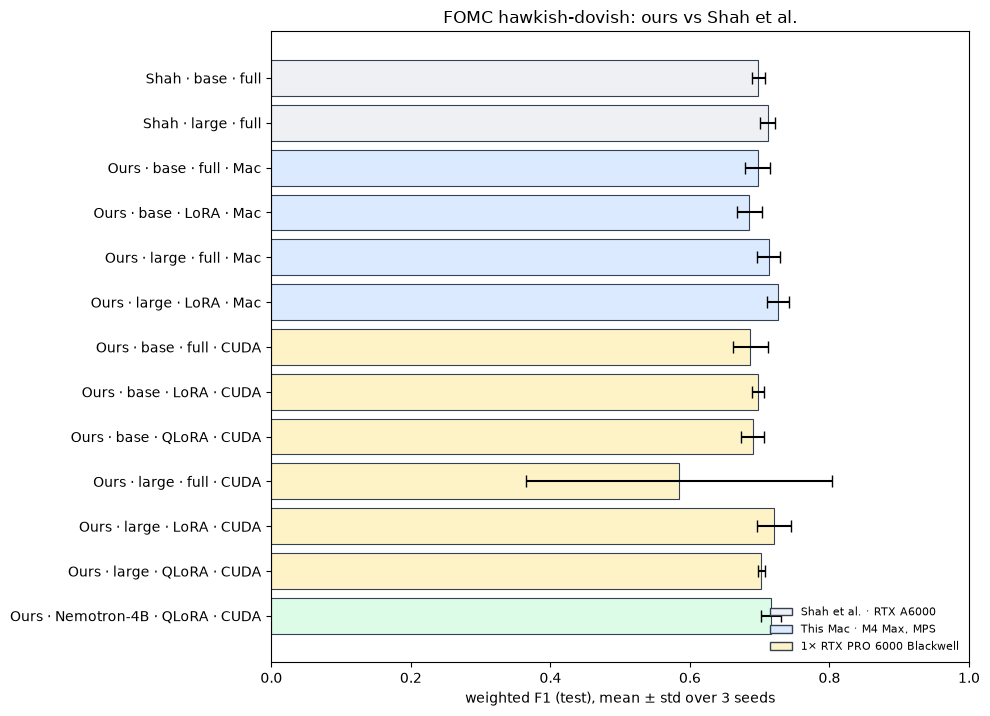

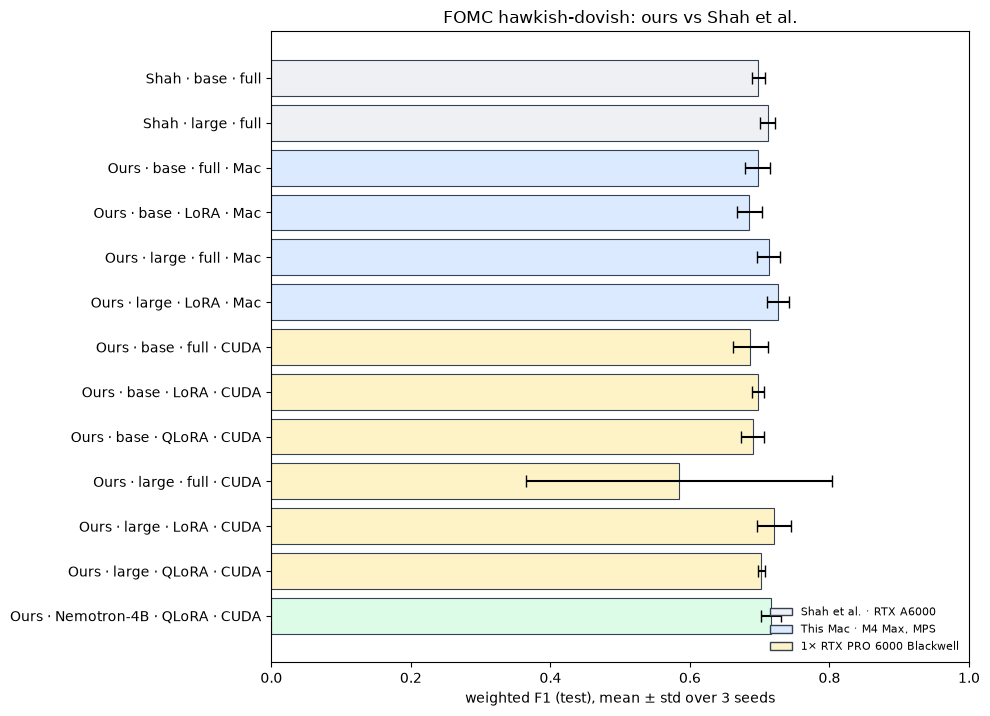

In [6]:
from report_helpers import machine_row_color

METHOD_LABEL = {"full": "full", "lora": "LoRA", "qlora": "QLoRA"}


def _hw_short(machine: str, who: str) -> str:
    if str(who).startswith("Shah"):
        return ""
    m = str(machine).lower()
    if "mac" in m or m.endswith("mps") or ", mps" in m:
        return "Mac"
    if "blackwell" in m or "cuda" in m or "h200" in m:
        return "CUDA"
    return ""


plot_df = summary.dropna(subset=["weighted_f1"]).copy()
# Shah comparison: keep published rows and 3-seed cells (including Nemotron LoRA / QLoRA).
if "n_seeds" in plot_df.columns:
    plot_df = plot_df[
        plot_df["who"].astype(str).str.startswith("Shah")
        | (plot_df["n_seeds"] >= 3)
    ].copy()
who = plot_df["who"].astype(str)
plot_df["who_short"] = np.where(who.str.startswith("Shah"), "Shah", "Ours")
plot_df["model_short"] = (
    plot_df["model"].astype(str)
    .str.replace("roberta-", "", regex=False)
    .str.replace("nemotron-nano-4b", "Nemotron-4B", regex=False)
)
plot_df["method_short"] = plot_df["method"].map(METHOD_LABEL).fillna(plot_df["method"])
if "machine" not in plot_df.columns:
    plot_df["machine"] = who.map(
        lambda w: "RTX A6000" if str(w).startswith("Shah") else "MacBook Pro M4 Max, 128 GB, MPS"
    )
plot_df["hw"] = [ _hw_short(m, w) for m, w in zip(plot_df["machine"], who) ]
plot_df["label"] = plot_df["who_short"] + " · " + plot_df["model_short"] + " · " + plot_df["method_short"]
has_hw = plot_df["hw"].astype(str).str.len() > 0
plot_df.loc[has_hw, "label"] = plot_df.loc[has_hw, "label"] + " · " + plot_df.loc[has_hw, "hw"]
# Same order as the Results table: Shah, Mac, CUDA; base before large; full / LoRA / QLoRA.
plot_df["_ord"] = (
    plot_df["who_short"].map({"Shah": 0, "Ours": 1}).fillna(2) * 100
    + plot_df["hw"].map({"": 0, "Mac": 1, "CUDA": 2}).fillna(3) * 10
    + plot_df["model_short"].map({"base": 0, "large": 1, "Nemotron-4B": 2}).fillna(3)
    + plot_df["method"].map({"full": 0.0, "lora": 0.1, "qlora": 0.2}).fillna(0.3)
)
plot_df = plot_df.sort_values("_ord")
colors = [machine_row_color(str(m)) for m in plot_df["machine"]]
std = plot_df["weighted_f1_std"].fillna(0) if "weighted_f1_std" in plot_df else 0
y = np.arange(len(plot_df))

fig, ax = plt.subplots(figsize=(10, max(4.8, 0.42 * len(plot_df) + 1.8)))
ax.barh(y, plot_df["weighted_f1"], xerr=std, capsize=4, color=colors, edgecolor="#344054", linewidth=0.8)
ax.set_yticks(y, plot_df["label"])
ax.invert_yaxis()
ax.set_xlabel("weighted F1 (test), mean ± std over 3 seeds")
ax.set_title("FOMC hawkish-dovish: ours vs Shah et al.")
ax.set_xlim(0, 1)
ax.legend(
    handles=[
        plt.Rectangle((0, 0), 1, 1, facecolor="#eef0f3", edgecolor="#344054", label="Shah et al. · RTX A6000"),
        plt.Rectangle((0, 0), 1, 1, facecolor="#dbeafe", edgecolor="#344054", label="This Mac · M4 Max, MPS"),
        plt.Rectangle((0, 0), 1, 1, facecolor="#fef3c7", edgecolor="#344054", label="1× RTX PRO 6000 Blackwell"),
    ],
    loc="lower right",
    frameon=False,
    fontsize=8,
)
fig.tight_layout()
fig


### Step 4: Load a checkpoint and classify new sentences

The next cell loads the **best finished run by test weighted F1** and prints **model, method, seed, and F1** before classifying. Override `RUN_DIR` to try another checkpoint. LoRA / QLoRA adapters live in `final/`; `load_trained` attaches them to that run's base (`roberta-base` or `roberta-large`).

In [7]:
runs = load_runs()
ours = runs[(runs["who"] == "ours") & (runs["status"] == "complete")]
if ours.empty:
    raise SystemExit("No finished runs yet, execute the grid cell first.")

best = ours.sort_values("weighted_f1", ascending=False).iloc[0]
RUN_DIR = Path(best["checkpoint_dir"])
method = str(best["method"])
method_disp = {"full": "full FT", "lora": "LoRA", "qlora": "QLoRA"}.get(method, method)
display(
    pd.DataFrame(
        [
            {
                "model": best["model"],
                "method": method_disp,
                "seed": int(best["seed"]),
                "test weighted F1": round(float(best["weighted_f1"]), 4),
                "machine": machine_label(best.get("device"), "ours"),
                "checkpoint": RUN_DIR.name,
            }
        ]
    )
)
model, tokenizer = load_trained(RUN_DIR)

examples = [
    "The Committee judged that a further increase in the target range would be appropriate.",
    "The Committee decided to lower the target range for the federal funds rate.",
    "Incoming data suggested that economic activity was expanding at a moderate pace.",
]
# Argmax class only, softmax scores are not calibrated probabilities.
rows = predict_texts(model, tokenizer, examples)
pd.DataFrame(rows)[["text", "pred_name"]]

,model,method,seed,test weighted F1,machine,checkpoint
0,nemotron-nano-4b,QLoRA,78516,0.7289,"RTX PRO 5000 Blackwell laptop, 24 GB, CUDA",nemotron-nano-4b__qlora__lab-manual-split-comb...


Loading weights:   0%|          | 0/263 [00:00<?, ?it/s]

Loading weights:   0%|          | 1/263 [00:00<00:41,  6.37it/s]

Loading weights:  13%|█▎        | 35/263 [00:00<00:01, 164.88it/s]

Loading weights:  26%|██▌       | 69/263 [00:00<00:00, 233.56it/s]

...

Loading weights:  66%|██████▌   | 173/263 [00:00<00:00, 291.50it/s]

Loading weights:  79%|███████▊  | 207/263 [00:00<00:00, 306.25it/s]

Loading weights:  92%|█████████▏| 243/263 [00:00<00:00, 322.29it/s]

Loading weights: 100%|██████████| 263/263 [00:01<00:00, 247.02it/s]

,text,pred_name
0,The Committee judged that a further increase i...,hawkish
1,The Committee decided to lower the target rang...,dovish
2,Incoming data suggested that economic activity...,hawkish


### Step 5: Serve the fine-tuned Nemotron with vLLM

QLoRA is a **training-memory** tool, not an **inference** tool. To serve, fold the adapter into the BF16 base (`merge_adapter`) and hand the merged checkpoint to [vLLM](https://github.com/vllm-project/vllm): paged KV cache and continuous batching instead of a padded `model(**batch)` loop.

The classifier does not need a new head. Training already scores the LM-head logits of three label tokens at the last prompt token, so vLLM generates **one token, restricted to those three ids** (`allowed_token_ids`), greedy. Same prompt ids, same argmax, same prediction.

- **Merged** (`serve_vllm.py merge`): one checkpoint, no adapter at request time. The production default.
- **Unmerged** (`eval --lora`): BF16 base + adapter attached per request. One base can hot-swap many adapters (per-tenant, per-task).
- **Flyte**: `merge_adapter` is a `@gpu_env.task` in `workflow.py`; `vllm_app` in `flyte_env.py` is a `VLLMAppEnvironment` ([flyteplugins-vllm](https://www.union.ai/docs/v2/flyte/user-guide/apps/native-app-integrations/vllm-app/)) that serves that task's output behind an OpenAI-compatible API.

vLLM pins its own torch, so it lives in a second venv (`.venv-vllm`). A QLoRA adapter was trained against an NF4 base; `eval` reports the merged vLLM F1 next to the training-time F1 so the gap is measured, not assumed.

In [8]:
# vLLM serving. Needs an NVIDIA GPU and a finished Nemotron LoRA / QLoRA run. Commented: Run All is safe.
cmds = """
cd NLP/Fine_Tuning/02_fomc_roberta
uv venv .venv-vllm --python 3.12 --managed-python   # managed build ships Python.h
VIRTUAL_ENV=.venv-vllm uv pip install vllm peft pandas openpyxl scikit-learn
VIRTUAL_ENV=.venv-vllm uv pip install flashinfer-jit-cache==<flashinfer version> --extra-index-url https://flashinfer.ai/whl/cu130
.venv/bin/python serve_vllm.py merge --method qlora --seed 5768
.venv-vllm/bin/python serve_vllm.py eval --method qlora --seed 5768          # merged
.venv-vllm/bin/python serve_vllm.py eval --method qlora --seed 5768 --lora   # unmerged adapter
# OpenAI-compatible server on this box:
# .venv-vllm/bin/vllm serve checkpoints/<run>/merged --served-model-name fomc-nemotron --max-model-len 512
# Same thing as a Flyte App (merge task output -> vLLM):
# flyte run workflow.py merge_adapter --method qlora --seed 5768
# flyte deploy workflow.py vllm_app
""".strip()
print(cmds)
# !{cmds}

cd NLP/Fine_Tuning/02_fomc_roberta
uv venv .venv-vllm --python 3.12 --managed-python   # managed build ships Python.h
VIRTUAL_ENV=.venv-vllm uv pip install vllm peft pandas openpyxl scikit-learn
VIRTUAL_ENV=.venv-vllm uv pip install flashinfer-jit-cache==<flashinfer version> --extra-index-url https://flashinfer.ai/whl/cu130
.venv/bin/python serve_vllm.py merge --method qlora --seed 5768
.venv-vllm/bin/python serve_vllm.py eval --method qlora --seed 5768          # merged
.venv-vllm/bin/python serve_vllm.py eval --method qlora --seed 5768 --lora   # unmerged adapter
# OpenAI-compatible server on this box:
# .venv-vllm/bin/vllm serve checkpoints/<run>/merged --served-model-name fomc-nemotron --max-model-len 512
# Same thing as a Flyte App (merge task output -> vLLM):
# flyte run workflow.py merge_adapter --method qlora --seed 5768
# flyte deploy workflow.py vllm_app


In [9]:
# vLLM vs PyTorch on the same test split (written by serve_vllm.py eval).
import json

vllm_rows = [json.loads(p.read_text()) for p in sorted(cfg.CHECKPOINTS_DIR.glob("*/vllm_metrics*.json"))]
if vllm_rows:
    display(pd.DataFrame(vllm_rows)[
        ["model", "method", "seed", "serving", "pytorch_weighted_f1", "vllm_weighted_f1", "sentences_per_second"]
    ])
else:
    print("No vLLM results yet. Run the commands above.")

,model,method,seed,serving,pytorch_weighted_f1,vllm_weighted_f1,sentences_per_second
0,nemotron-nano-4b,qlora,5768,vllm-merged,0.700265,0.701632,80.7
1,nemotron-nano-4b,qlora,5768,vllm-lora,0.700265,0.699344,72.1


## CLI (same `workflow.py` locally and remotely)

Flyte 2 has no `@workflow`. You define a `TaskEnvironment`, then decorate functions with `@env.task` ([tasks](https://www.union.ai/docs/v2/flyte/user-guide/get-started/core-concepts/tasks/), [configuration](https://www.union.ai/docs/v2/union/user-guide/tasks/task-configuration/)). Those objects live in `flyte_env.py` / `workflow.py`. This notebook **imports them**: it does not define a second DAG.

- **`@cpu_env.task` `prepare_data`**: Combined-S xlsx (`cache="auto"`).
- **`@gpu_env.task` `train_one` / `grid`**: same function on the Mac (`gpu=0`, MPS) and on a remote NVIDIA GPU (CUDA, QLoRA, Nemotron).
- **`@ui_env.task` `main`**: snapshot + talk Report. Drivers call children → **Sub actions**.

Flyte 2 is the point: **laptop** `flyte run --local` (RoBERTa follow-along), **remote GPU** `bash run_fomc.sh` (RoBERTa 2×3 on the card you already have). Adding Nemotron is `--model_key nemotron-nano-4b` on that same DAG, Combined-S, not SQL. A Flyte **devbox** on a laptop with Docker is how you later watch the remote run in the browser (`:30080`). Without Docker, the job itself is in-process on the GPU node.

All three command cells are commented so Run All does not start training.


In [10]:
# This MacBook Pro (M4 Max), talk report in the browser. Commented: Run All is safe.
# Uncomment to run in this kernel, or run the cell and paste the printed block into a terminal.
cmds = """
cd NLP/Fine_Tuning/02_fomc_roberta
source .venv/bin/activate
flyte start devbox
flyte get devbox
flyte -c .flyte/devbox.yaml run --name fomc-talk workflow.py main
# http://localhost:30080/v2/domain/development/project/flytesnacks/runs/fomc-talk
# Reports = hawkish/dovish/neutral + live F1. Sub actions = one cell_summary per finished run.
""".strip()
print(cmds)
# !{cmds}

cd NLP/Fine_Tuning/02_fomc_roberta
source .venv/bin/activate
flyte start devbox
flyte get devbox
flyte -c .flyte/devbox.yaml run --name fomc-talk workflow.py main
# http://localhost:30080/v2/domain/development/project/flytesnacks/runs/fomc-talk
# Reports = hawkish/dovish/neutral + live F1. Sub actions = one cell_summary per finished run.


In [11]:
# This MacBook Pro, in-process MPS. Terminal TUI, not :30080. Commented: Run All is safe.
cmds = """
cd NLP/Fine_Tuning/02_fomc_roberta
source .venv/bin/activate
flyte run --local --tui workflow.py pipeline --model_key roberta-base --method lora --seed 5768
flyte run --local --tui workflow.py grid
# or: python workflow.py
""".strip()
print(cmds)
# !{cmds}

cd NLP/Fine_Tuning/02_fomc_roberta
source .venv/bin/activate
flyte run --local --tui workflow.py pipeline --model_key roberta-base --method lora --seed 5768
flyte run --local --tui workflow.py grid
# or: python workflow.py


In [12]:
# Remote GPU node. In-process CUDA (no Docker/devbox). Commented: Run All is safe.
cmds = """
cd NLP/Fine_Tuning/02_fomc_roberta
bash run_fomc.sh
# bash run_fomc.sh qlora
# bash run_fomc.sh pipeline
# After RoBERTa 2x3, Nemotron labeltok (does not overwrite the first paper-loop grid):
# bash run_fomc.sh nemotron-lora
# python train_run.py --model nemotron-nano-4b --method lora --seed 5768
# 3-seed grid: bash run_fomc.sh nemotron
# Laptop later (Docker): flyte start devbox --gpu  ->  browser at :30080
""".strip()
print(cmds)
# !{cmds}

cd NLP/Fine_Tuning/02_fomc_roberta
bash run_fomc.sh
# bash run_fomc.sh qlora
# bash run_fomc.sh pipeline
# After RoBERTa 2x3, Nemotron labeltok (does not overwrite the first paper-loop grid):
# bash run_fomc.sh nemotron-lora
# python train_run.py --model nemotron-nano-4b --method lora --seed 5768
# 3-seed grid: bash run_fomc.sh nemotron
# Laptop later (Docker): flyte start devbox --gpu  ->  browser at :30080
